In [27]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import scipy.stats as stats
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

In [49]:
df_clean = pd.read_csv('../data/data_clean.csv')
print(df_clean.columns)
df_labels = df_clean.copy()[['class_primary','class_secondary','attack']]
df_names = df_clean['english_name']
df_data = df_clean.drop(columns=['english_name','class_primary','class_secondary','attack'])

Index(['gen', 'english_name', 'percent_male', 'percent_female', 'height_m',
       'weight_kg', 'capture_rate', 'base_egg_steps', 'hp', 'attack',
       'defense', 'sp_attack', 'sp_defense', 'speed', 'against_normal',
       'against_fire', 'against_water', 'against_electric', 'against_grass',
       'against_ice', 'against_fighting', 'against_poison', 'against_ground',
       'against_flying', 'against_psychict', 'against_bug', 'against_rock',
       'against_ghost', 'against_dragon', 'against_dark', 'against_steel',
       'against_fairy', 'votes_first', 'votes_top_6', 'num_abilities',
       'evo_length', 'has_mega_evolution', 'has_gigantamax', 'rarity',
       'class_primary', 'class_secondary'],
      dtype='object')


### EDA

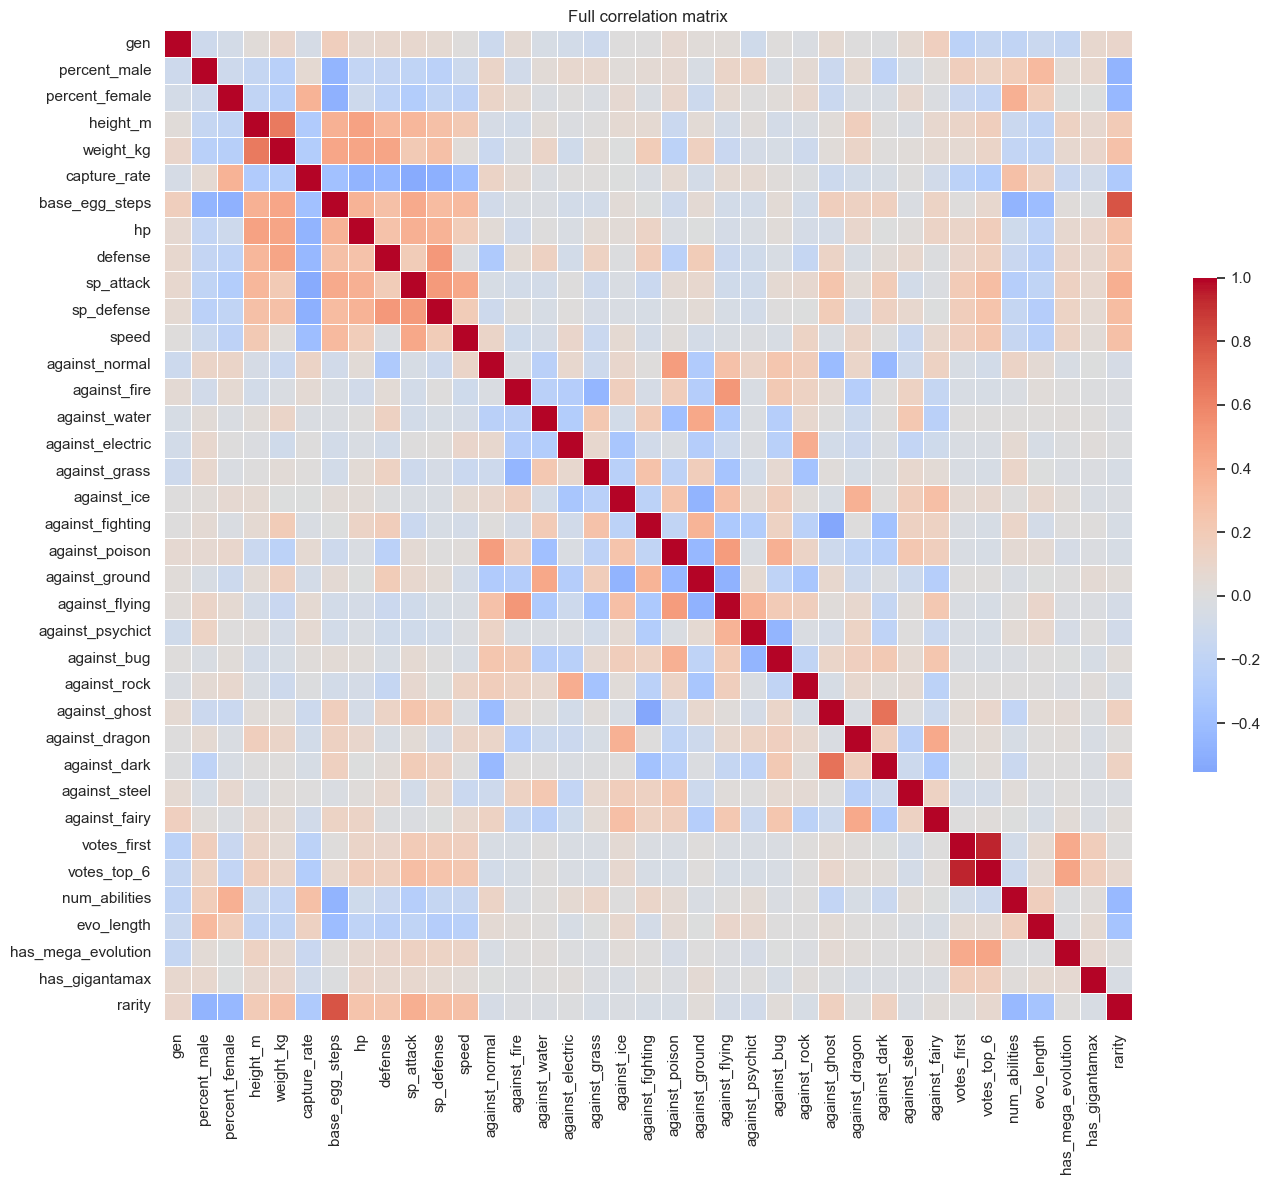

Top correlated variable pairs (by absolute correlation):
            var1           var2  abs_corr
     votes_first    votes_top_6  0.934181
  base_egg_steps         rarity  0.790583
   against_ghost   against_dark  0.676126
        height_m      weight_kg  0.642715
against_fighting  against_ghost  0.554569
    capture_rate      sp_attack  0.522649
    against_fire against_flying  0.510980
         defense     sp_defense  0.507367
    capture_rate     sp_defense  0.499831
       sp_attack     sp_defense  0.491907
  against_poison against_flying  0.488559
  percent_female base_egg_steps  0.481715
  against_ground against_flying  0.480854
  against_normal against_poison  0.478127
     against_ice against_ground  0.473085
    capture_rate             hp  0.470610
  base_egg_steps  num_abilities  0.467755
    percent_male         rarity  0.466875
against_psychict    against_bug  0.461637
    percent_male base_egg_steps  0.458000


In [30]:
# compute correlation matrix for all numeric parameters
numeric = df_data.select_dtypes(include=[np.number])
corr = numeric.corr()

plt.figure(figsize=(14, 12))
sns.set(style="white")
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, fmt=".2f",
            linewidths=0.5, cbar_kws={"shrink": .5})
plt.title("Full correlation matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150)
plt.show()

# show top absolute correlations (excluding self-correlations) as a quick summary
abs_corr = corr.abs()
pairs = (
    abs_corr.unstack()
    .reset_index()
    .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'abs_corr'})
)
pairs = pairs[pairs['var1'] != pairs['var2']]
# keep unique pairs (unordered) and sort by absolute correlation
pairs['pair_key'] = pairs.apply(lambda r: tuple(sorted((r['var1'], r['var2']))), axis=1)
top_pairs = pairs.drop_duplicates(subset='pair_key').sort_values('abs_corr', ascending=False)

print("Top correlated variable pairs (by absolute correlation):")
print(top_pairs[['var1', 'var2', 'abs_corr']].head(20).to_string(index=False))



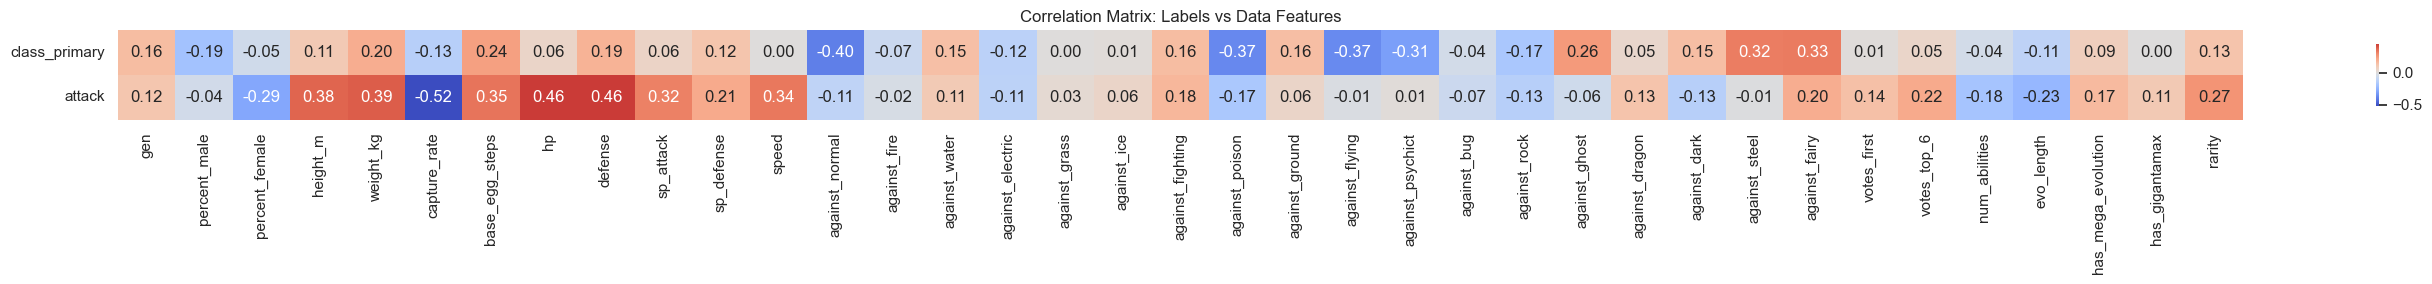

Top correlated label-feature pairs (by absolute correlation):
        label          feature  abs_corr
       attack     capture_rate  0.520709
       attack               hp  0.457134
       attack          defense  0.455193
class_primary   against_normal  0.395097
       attack        weight_kg  0.393770
       attack         height_m  0.377788
class_primary   against_poison  0.371248
class_primary   against_flying  0.367354
       attack   base_egg_steps  0.349379
       attack            speed  0.337449
class_primary    against_fairy  0.330422
class_primary    against_steel  0.324446
       attack        sp_attack  0.319612
class_primary against_psychict  0.306973
       attack   percent_female  0.286821
       attack           rarity  0.273122
class_primary    against_ghost  0.258438
class_primary   base_egg_steps  0.242525
       attack       evo_length  0.232292
       attack      votes_top_6  0.215905


In [45]:
# Compute correlation matrix between all columns in df_labels (excluding secondary_type) and all columns in df_data
label_cols = ['class_primary', 'attack']
corr_matrix = df_labels[label_cols].join(df_data).corr()

# Extract only correlations between label columns and data columns (exclude label-label and data-data)
corr_pairs = []
for label in label_cols:
    for col in df_data.columns:
        corr_val = corr_matrix.loc[label, col]
        corr_pairs.append((label, col, corr_val))

# Convert to DataFrame and sort by absolute correlation
corr_df = pd.DataFrame(corr_pairs, columns=['label', 'feature', 'corr'])
corr_df['abs_corr'] = corr_df['corr'].abs()
top_corr = corr_df.sort_values('abs_corr', ascending=False).drop(columns=['corr'])

# Show correlation matrix as heatmap (very wide)
plt.figure(figsize=(28, 3))
sns.heatmap(
    corr_matrix.loc[label_cols, df_data.columns],
    annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar_kws={"shrink": .7}
)
plt.title("Correlation Matrix: Labels vs Data Features")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print most correlated pairs
print("Top correlated label-feature pairs (by absolute correlation):")
print(top_corr.head(20).to_string(index=False))

C:\Users\jenda\AppData\Local\Temp\ipykernel_33280\152769910.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=temp['gen_int'], y=df_labels['attack'], palette="Set3")


Attack quantiles by generation:
          0.00   0.25  0.50    0.75   1.00
gen_int                                  
1         5.0  51.00  70.0   92.00  134.0
2        10.0  49.75  67.5   85.00  134.0
3        15.0  50.00  70.0   90.00  160.0
4         5.0  60.00  80.0  100.00  165.0
5        25.0  55.00  77.5  100.00  150.0
6        22.0  52.00  69.0   90.50  131.0
7        20.0  60.00  76.5  112.25  181.0
8        20.0  60.00  85.0  100.00  145.0


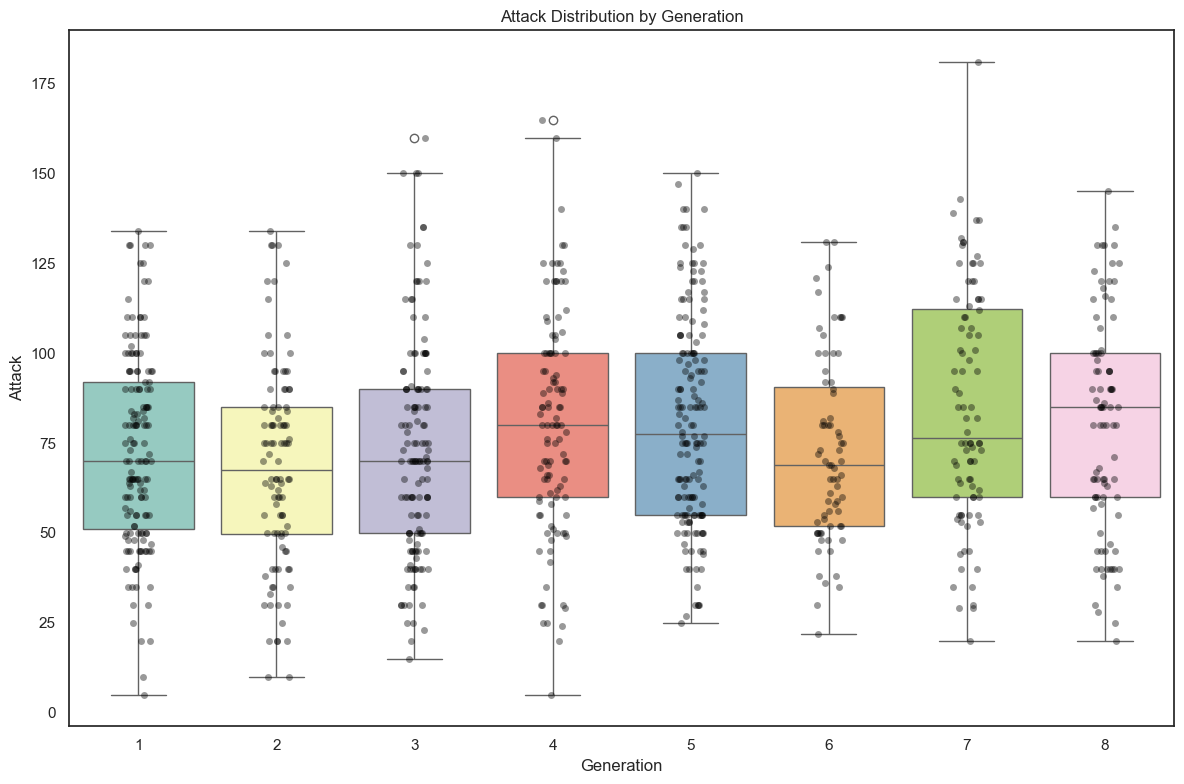

<Figure size 640x480 with 0 Axes>

In [46]:
temp = pd.DataFrame()
temp['gen_int'] = df_data['gen'].astype(int)
temp['rarity'] = df_data['rarity']

plt.figure(figsize=(12, 8))
sns.boxplot(x=temp['gen_int'], y=df_labels['attack'], palette="Set3")
sns.stripplot(x=temp['gen_int'], y=df_labels['attack'], color='black', alpha=0.4, jitter=True)

# Calculate and print quantiles for each generation
quantiles = df_labels.groupby(temp['gen_int'])['attack'].quantile([0, 0.25, 0.5, 0.75, 1]).unstack()
print("Attack quantiles by generation:\n", quantiles)

plt.title("Attack Distribution by Generation")
plt.xlabel("Generation")
plt.ylabel("Attack")
plt.tight_layout()
plt.show()

plt.savefig("attack_by_generation_boxplot.png", dpi=150)

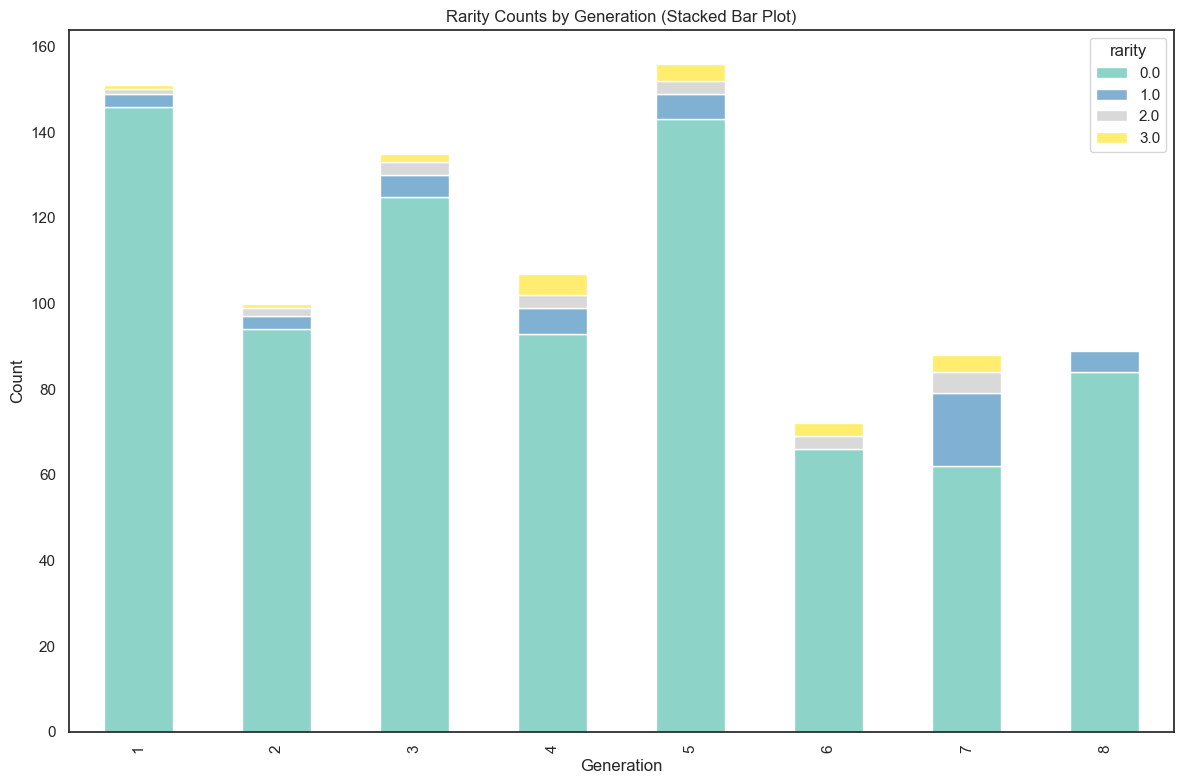

In [47]:
plt.figure(figsize=(12, 8))
rarity_counts = temp.groupby(['gen_int', 'rarity']).size().unstack(fill_value=0)
rarity_counts.plot(kind='bar', stacked=True, colormap='Set3', ax=plt.gca())

plt.title("Rarity Counts by Generation (Stacked Bar Plot)")
plt.xlabel("Generation")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


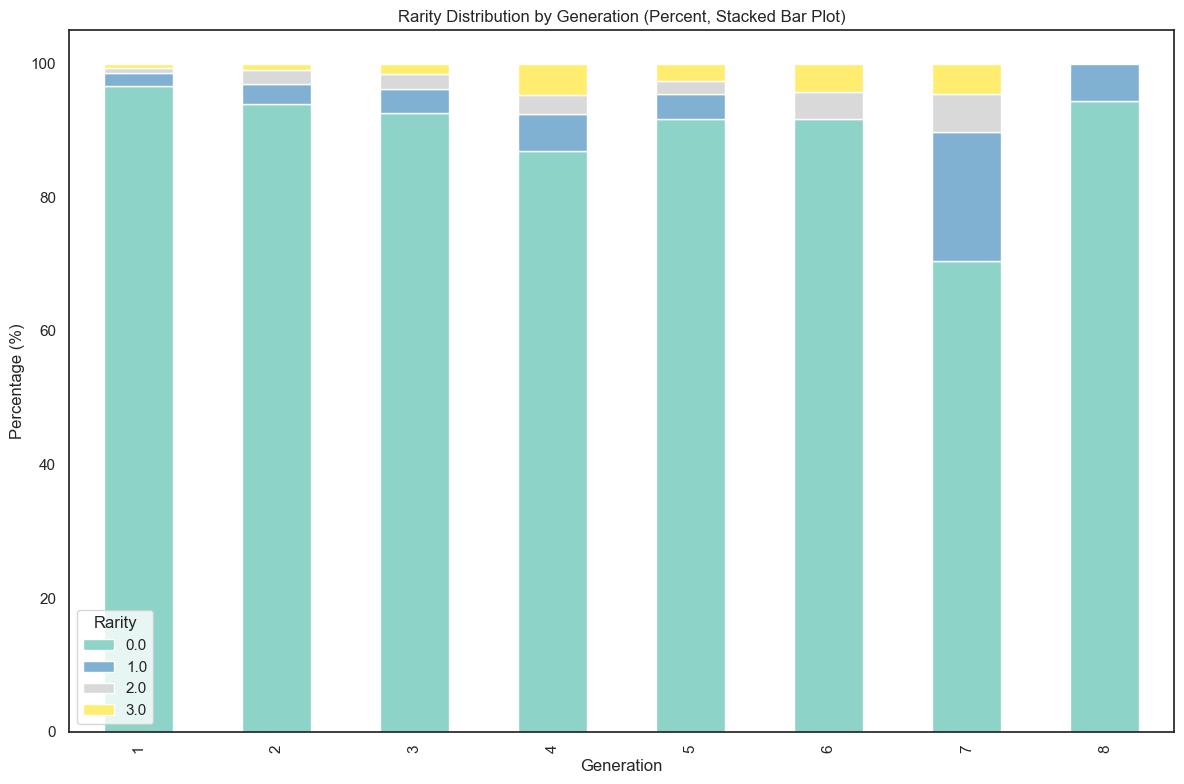

In [48]:
# Calculate rarity counts as percentages within each generation
rarity_percent = rarity_counts.div(rarity_counts.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 8))
rarity_percent.plot(kind='bar', stacked=True, colormap='Set3', ax=plt.gca())

plt.title("Rarity Distribution by Generation (Percent, Stacked Bar Plot)")
plt.xlabel("Generation")
plt.ylabel("Percentage (%)")
plt.legend(title="Rarity")
plt.tight_layout()
plt.show()

### Outliers

Index(['gen', 'percent_male', 'percent_female', 'height_m', 'weight_kg',
       'capture_rate', 'base_egg_steps', 'hp', 'defense', 'sp_attack',
       'sp_defense', 'speed', 'against_normal', 'against_fire',
       'against_water', 'against_electric', 'against_grass', 'against_ice',
       'against_fighting', 'against_poison', 'against_ground',
       'against_flying', 'against_psychict', 'against_bug', 'against_rock',
       'against_ghost', 'against_dragon', 'against_dark', 'against_steel',
       'against_fairy', 'votes_first', 'votes_top_6', 'num_abilities',
       'evo_length', 'has_mega_evolution', 'has_gigantamax', 'rarity'],
      dtype='object')
outlier
 1    853
-1     45
Name: count, dtype: int64


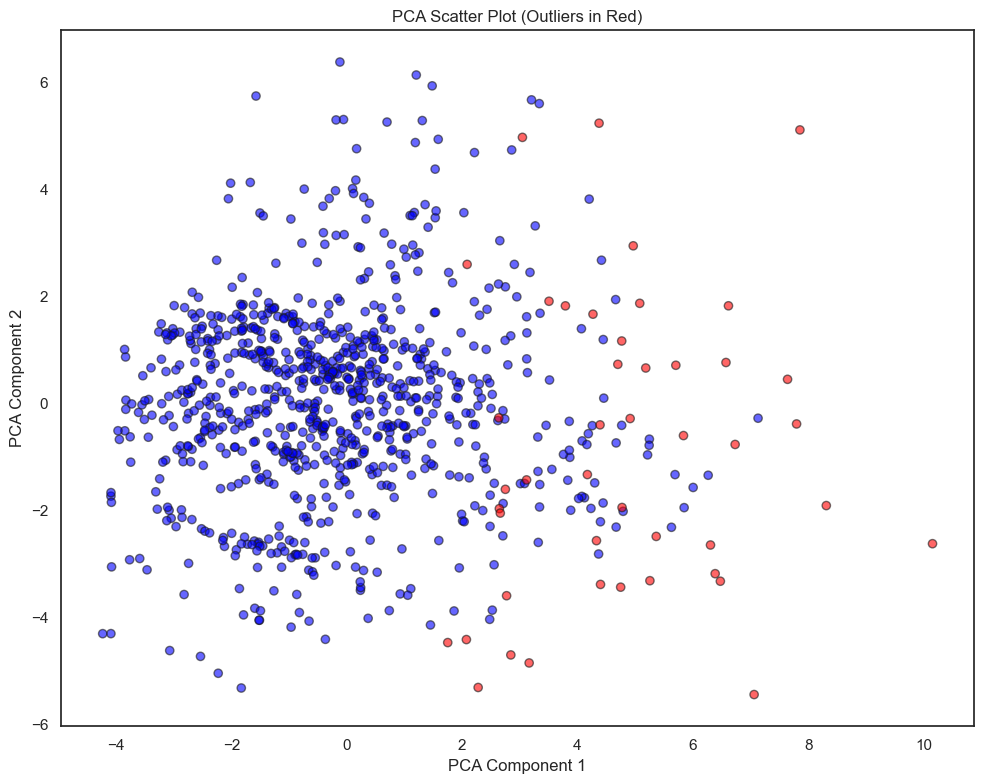

In [35]:
# Standardize all features in df_plot
scaler= StandardScaler()
pca = PCA(n_components=2)

print(df_data.columns)
outlier_data = df_data.copy().drop(['rarity'],axis=1)
df_plot_scaled = pd.DataFrame(scaler.fit_transform(outlier_data), columns=outlier_data.columns)
pca.fit(df_plot_scaled)

# Fit Isolation Forest for outlier detection
iso = IsolationForest(contamination=0.05, random_state=42)
outlier_pred = iso.fit_predict(df_plot_scaled)

# Add outlier flag to dataframe: -1 is outlier, 1 is inlier
df_plot_scaled['outlier'] = outlier_pred
print(df_plot_scaled['outlier'].value_counts())

pca_data = pca.transform(df_plot_scaled.drop(columns=['outlier']))
plt.figure(figsize=(10, 8))
colors = np.where(df_plot_scaled['outlier'] == -1, 'red', 'blue')
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=colors, alpha=0.6, edgecolor='k')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA Scatter Plot (Outliers in Red)')
plt.tight_layout()
plt.show()

In [36]:
# Print names of the outliers, ordered by outlier score (most outlier-like first)
outlier_scores = iso.decision_function(df_plot_scaled.drop(columns=['outlier']))
outlier_indices = np.where(outlier_mask)[0]
outlier_scores_selected = outlier_scores[outlier_indices]
outlier_names = df_names.loc[outlier_mask]
# Map rarity values to string labels
rarity_map = {0.0: "common", 1.0: "sublegendary", 2.0: "legendary", 3.0: "mythical"}
outlier_rarity_str = outlier_rarity.map(rarity_map)

# Combine names, rarity (as string), and scores, sort by score ascending (most negative = most outlier)
outlier_df = pd.DataFrame({
    'name': outlier_names.values,
    'rarity': outlier_rarity_str.values,
    'score': outlier_scores_selected
})
outlier_df_sorted = outlier_df.sort_values('score').drop(columns=['score']).reset_index(drop=True)

print("Names and rarity of outliers ordered by Isolation Forest outlier score:")
print(outlier_df_sorted)

Names and rarity of outliers ordered by Isolation Forest outlier score:
           name        rarity
0        Gengar        common
1      Rayquaza     legendary
2     Stakataka  sublegendary
3      Giratina     legendary
4     Eternatus        common
5     Tyranitar        common
6     Metagross        common
7       Diancie      mythical
8      Guzzlord  sublegendary
9        Mewtwo     legendary
10       Lunala     legendary
11       Aggron        common
12    Charizard        common
13       Latios  sublegendary
14       Latias  sublegendary
15  Blacephalon  sublegendary
16     Melmetal        common
17       Zarude        common
18      Steelix        common
19   Celesteela  sublegendary
20      Urshifu  sublegendary
21        Hoopa      mythical
22    Marshadow      mythical
23        Lugia     legendary
24       Celebi      mythical
25     Gyarados        common
26     Solgaleo     legendary
27     Buzzwole  sublegendary
28    Pheromosa  sublegendary
29        Ho-Oh     legendar

In [37]:
# Remove outliers from all relevant dataframes using outlier_mask
df_labels_no_outliers = df_labels.loc[~outlier_mask].reset_index(drop=True)
df_names_no_outliers = df_names.loc[~outlier_mask].reset_index(drop=True)
df_data_no_outliers = df_data.loc[~outlier_mask].reset_index(drop=True)

# Merge them into one DataFrame
df_no_outliers = pd.concat(
    [df_names_no_outliers, df_labels_no_outliers, df_data_no_outliers], axis=1
)

# Save to CSV
df_no_outliers.to_csv('../data/data_no_outliers.csv', index=False)


Outlier rarity counts:
 rarity
0.0    16
1.0    12
2.0    11
3.0     6
Name: count, dtype: int64
Outlier rarity percentages (%):
 rarity
0.0    35.56
1.0    26.67
2.0    24.44
3.0    13.33
Name: count, dtype: float64

Full population rarity counts:
 rarity
0.0    813
1.0     45
2.0     20
3.0     20
Name: count, dtype: int64
Full population rarity percentages (%):
 rarity
0.0    90.53
1.0     5.01
2.0     2.23
3.0     2.23
Name: count, dtype: float64


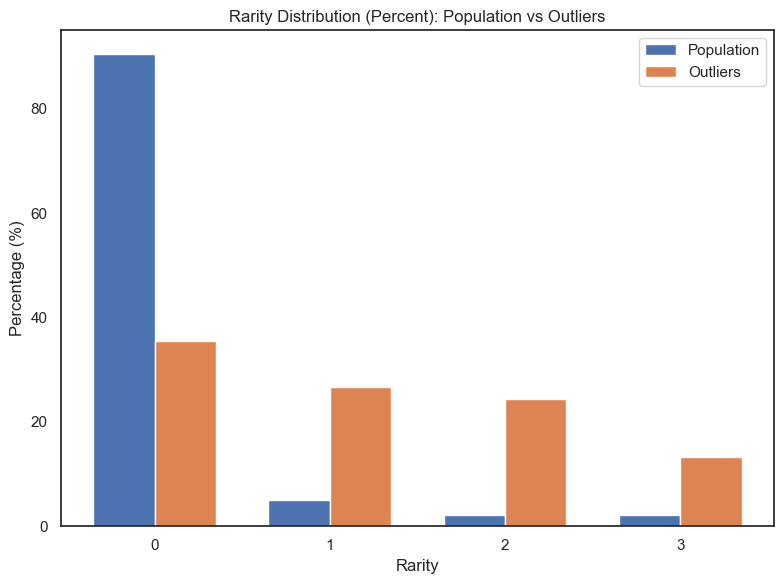

In [38]:
# Rarity of outliers
outlier_mask = outlier_pred == -1
rarity_outliers = temp.loc[outlier_mask, 'rarity']
rarity_full = temp['rarity']

# Count and percentage for outliers
outlier_counts = rarity_outliers.value_counts().sort_index()
outlier_percent = (outlier_counts / len(rarity_outliers) * 100).round(2)

print("Outlier rarity counts:\n", outlier_counts)
print("Outlier rarity percentages (%):\n", outlier_percent)

# Count and percentage for full population
full_counts = rarity_full.value_counts().sort_index()
full_percent = (full_counts / len(rarity_full) * 100).round(2)

print("\nFull population rarity counts:\n", full_counts)
print("Full population rarity percentages (%):\n", full_percent)


# Bar plot: percentages
plt.figure(figsize=(8, 6))
plt.bar(x - bar_width/2, full_percent[x], width=bar_width, label='Population')
plt.bar(x + bar_width/2, outlier_percent[x], width=bar_width, label='Outliers')
plt.xlabel('Rarity')
plt.ylabel('Percentage (%)')
plt.title('Rarity Distribution (Percent): Population vs Outliers')
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()

### Classification via linear classifier

In [44]:
#calculate cross-validated accuracy for logistic regression predicting class_primary
X = df_data
y = df_labels['class_primary']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)
fold_acc = []
for i, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler_fold = StandardScaler()
    X_train_scaled = scaler_fold.fit_transform(X_train)
    X_val_scaled = scaler_fold.transform(X_val)

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_val_scaled)

    acc = accuracy_score(y_val, y_pred)
    print(f"Fold {i} accuracy: {acc:.4f}")
    fold_acc.append(acc)

print(f"Mean CV accuracy: {np.mean(fold_acc):.4f} (+/- {np.std(fold_acc):.4f})")

Fold 1 accuracy: 0.9167
Fold 2 accuracy: 0.9167
Fold 3 accuracy: 0.8611
Fold 4 accuracy: 0.8939
Fold 5 accuracy: 0.9385
Mean CV accuracy: 0.9054 (+/- 0.0263)
